<a href="https://colab.research.google.com/github/Gaenariya/Kimnaryeong/blob/main/05_titanic_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


/tmp/ipykernel_3122/1393212883.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["age"].fillna(data["age"].median(), inplace=True)
/tmp/ipykernel_3122/1393212883.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

정확도: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from

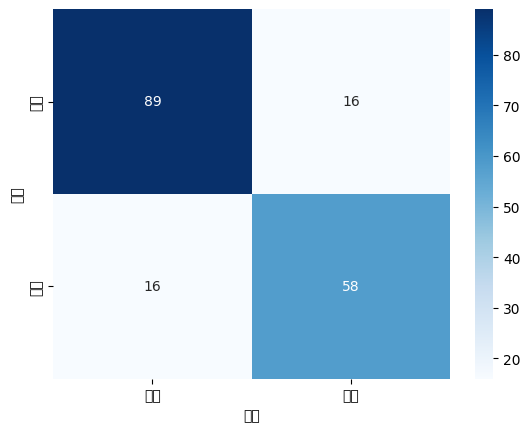

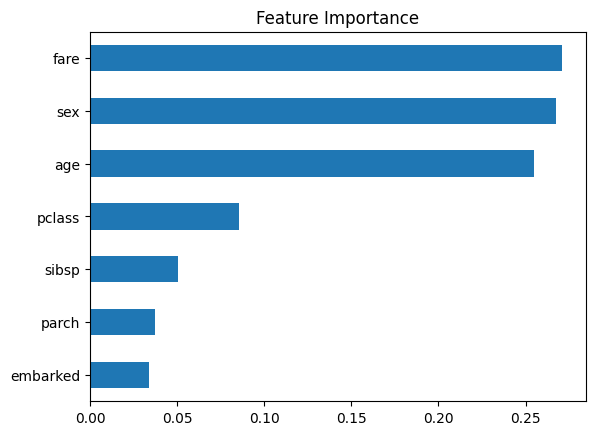

In [1]:
# 05. 타이타닉 생존자 예측 (scikit-learn)
# Google Colab에 그대로 복사해서 셀 단위(# %%)로 실행하면 됩니다.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# %% 데이터 불러오기 (seaborn 내장 타이타닉 데이터셋 사용)
df = sns.load_dataset("titanic")
df.head()

# %% 결측치 및 컬럼 확인
print(df.isnull().sum())

# %% 전처리: 필요한 컬럼만 선택, 결측치 처리, 범주형 인코딩
data = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()
data["age"].fillna(data["age"].median(), inplace=True)
data["embarked"].fillna(data["embarked"].mode()[0], inplace=True)

data["sex"] = data["sex"].map({"male": 0, "female": 1})
data["embarked"] = data["embarked"].map({"S": 0, "C": 1, "Q": 2})

# %% 특징(X)과 정답(y) 분리
X = data.drop("survived", axis=1)
y = data["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# %% 모델 학습 (RandomForest)
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# %% 평가
y_pred = model.predict(X_test)
print("정확도:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# %% 혼동 행렬 시각화
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["사망", "생존"], yticklabels=["사망", "생존"])
plt.xlabel("예측")
plt.ylabel("실제")
plt.show()

# %% 특징 중요도 시각화
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()